# P6: Learning about LLMs, Finetuning and RAG

This single notebook covers all three sections of P6.
- **Sections 1 & 2** require a T4 GPU (free Google Colab).
- **Section 3** (RAG) can run on the same T4 session or on a CPU-only runtime.

## Section 0: Setup

> **Runtime note**: Select **T4 GPU** in Colab: *Runtime → Change runtime type → T4 GPU*. Sections 1 & 2 require a GPU. Section 3 (RAG) does **not** require a GPU — you can stay on T4 or switch to a CPU-only runtime to conserve quota.

In [1]:
# NO CHANGE
# Q0 — Verify that CUDA / T4 GPU is available before running model cells.
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: NVIDIA A100-SXM4-80GB


### Step 1: Install all dependencies

Run this cell once at the start of your session. It covers all three sections.

In [2]:
# NO CHANGE
# Q0 — Install all project dependencies (bitsandbytes, transformers, trl, haystack, chromadb, etc.).
# ⚠️  Re-run this cell after every runtime restart — pip installs are lost when the session ends.
# %reset -f (used at the start of Section 3) only clears Python variables;
# packages remain installed and do NOT need to be reinstalled after %reset -f.

!pip install bitsandbytes>=0.39.0
!pip install --upgrade accelerate transformers datasets peft trl
!pip install streamlit nltk
!npm install -g localtunnel
!pip install sentence-transformers
!pip install chromadb
!pip install haystack-ai elasticsearch-haystack
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 892ms
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇Requirement already satisfied: sentence-transformers in /usr/local/lib/python3.12/dist-packages (5.4.1)
⠙⠹⠸⠼
changed 22 packages in 585ms
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

### Step 2: Download lecture transcripts

In [3]:
# NO CHANGE
# Q0 — Unzip the 23 CS 639 lecture transcript .txt files from the course GitHub.
!unzip transcripts.zip -d transcripts/

Archive:  transcripts.zip
replace transcripts/__MACOSX/._transcripts? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: transcripts/__MACOSX/._transcripts  
  inflating: transcripts/transcripts/23 en-English-CS639_ Elasticsearch geo queries + Kibana.txt  
  inflating: transcripts/__MACOSX/transcripts/._23 en-English-CS639_ Elasticsearch geo queries + Kibana.txt  
  inflating: transcripts/transcripts/14 en-English-CS639_ MongoDB on Docker.txt  
  inflating: transcripts/__MACOSX/transcripts/._14 en-English-CS639_ MongoDB on Docker.txt  
  inflating: transcripts/transcripts/.DS_Store  
  inflating: transcripts/__MACOSX/transcripts/._.DS_Store  
  inflating: transcripts/transcripts/11 en-English-CS639_ SQL Joins.txt  
  inflating: transcripts/__MACOSX/transcripts/._11 en-English-CS639_ SQL Joins.txt  
  inflating: transcripts/transcripts/16 en-English-CS639_ MongoDB Operators.txt  
  inflating: transcripts/__MACOSX/transcripts/._16 en-English-CS639_ MongoDB Operators.txt  
  inflating: 

### Step 3: HuggingFace login

Enter your HuggingFace API token when prompted.

In [4]:
# NO CHANGE
# Q0 — Authenticate with HuggingFace Hub to access the gated Llama-3.2-1B-Instruct model.
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


---
## Section 1: Text Generation with a Pre-Trained LLM

### Q1.1: Load a 4-bit quantized `Llama-3.2-1B-Instruct` model and its tokenizer

In [49]:
# NO CHANGE
# Q1.1 — Load the 4-bit NF4-quantized Llama-3.2-1B-Instruct model and its tokenizer onto the GPU.
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "meta-llama/Llama-3.2-1B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

print(f"Model loaded on device: {device}")
print(f"Model dtype: {model.dtype}")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Model loaded on device: cuda
Model dtype: torch.bfloat16


### Q1.2: Test your quantized model with different prompts

In [50]:
# TO IMPLEMENT
# Q1.2 — Test 3 prompts (at least one UW-Madison related).
def generate_response(prompt, model, tokenizer, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

# FILL THE 3 PROMPTS HERE
prompts = [
    "Explain the main differences between a SQL and a NoSQL database in one paragraph.",
    "What are the best places to study on the UW-Madison campus?",
    "Write a short python function to calculate the Fibonacci sequence."
]

assert len(prompts) == 3

for p in prompts:
    print(f"Prompt: {p}")
    response = generate_response(p, model, tokenizer)
    print(f"Response: {response}")
    print("-" * 80)

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Prompt: Explain the main differences between a SQL and a NoSQL database in one paragraph.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Response:  The main differences between a SQL and a NoSQL database are:
- SQL databases store data in tables with fixed column names and are optimized for structured, relational data. NoSQL databases, on the other hand, store data in flexible, semi-structured or unstructured formats, such as documents, graphs, or arrays, and are optimized for handling large amounts of semi-structured or unstructured data. SQL databases are optimized for relational data, while NoSQL databases are optimized for handling a wide variety of data types.
- SQL databases are optimized for querying and retrieving data in a specific, predefined order. NoSQL databases are optimized for handling a wide variety of queries and retrieving data in a flexible, non-predefined order. SQL databases are optimized for using complex queries, while NoSQL databases are optimized for using simple queries.
- SQL databases store data in a fixed, predefined schema, while NoSQL databases store data in a flexible, schema-less format

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Response: ?
The University of Wisconsin–Madison (UW–Madison) offers a variety of excellent study spaces for students to focus, relax, or work. Some of the best places to study on the UW-Madison campus include:

1. The Madison Student Union: This is a popular spot for students to study, socialize, and enjoy a variety of amenities such as a game room, a cafe, and a bookstore.

2. The University Center (UC): The UC is a large, open space that serves as a hub for students to study, collaborate, and engage with faculty and staff. It features a variety of study areas, including a quiet room and a collaborative space.

3. The Student Union Building (SUB): The SUB is a smaller space that provides students with a quiet, comfortable space to study and relax. It features a variety of study areas, including a quiet room and a collaborative space.

4. The Arboretum: The Arboretum is a beautiful,
--------------------------------------------------------------------------------
Prompt: Write a short p

### Q1.3: Analyze the prompt for which the model fails.

In [51]:
# NO CHANGE
# Q1.3 — Run the failing prompt
failing_prompt = "What were the exact exam questions on the CS 639 midterm at UW-Madison in Spring 2025?"
print(f"Prompt: {failing_prompt}")
response = generate_response(failing_prompt, model, tokenizer)
print(f"Response: {response}")

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Prompt: What were the exact exam questions on the CS 639 midterm at UW-Madison in Spring 2025?
Response:  I'm trying to understand what was covered in the exam.

Unfortunately, I was not able to find the exact exam questions on the CS 639 midterm at UW-Madison in Spring 2025. However, I can try to provide you with some information on what was typically covered on the exam.

In the CS 639 midterm at UW-Madison, the exam typically covers the following topics:

* Programming languages (e.g. Python, Java, C++): Questions about syntax, semantics, and type systems.
* Data structures and algorithms: Questions about data structures (e.g. trees, graphs, arrays), sorting, and searching algorithms (e.g. quicksort, mergesort).
* Computer systems: Questions about computer architecture, operating systems, and computer networks.
* Software engineering: Questions about software design patterns, testing, and debugging.
* Machine learning and artificial intelligence: Questions about machine learning alg

**Q1.3: Add your Analysis of Model Failure here in this markdown**

Reason:   
Knowledge Cut-off / Future Events: The model was trained on a dataset collected before 2025. It can't know the exact contents of an exam from Spring 2025 because that information did not yet exist during its training.

Proprietary/Private Information: Even if the exam had already happened, exact midterm questions for specific university courses (like CS 639 at UW-Madison) are not usually public but are rather kept private on secure platforms like Canvas. Thus an LLM would not be able to scrape them from the open web in order to learn from them.

Hallucination: The model doesn't have the actual answer so it attempts to produce a plausible continuation, "hallucinating" or making up unverified facts (like confidently guessing that it is a "multiple-choice exam" administered in a "computer-based format").

### Q1.4: Enhance model responses using chat templates

In [52]:
# NO CHANGE
# Q1.4 — Apply a role-playing system prompt via chat template and generate a response.
messages = [
    {
        "role": "system",
        "content": "You are a medieval scholar who speaks in archaic English and uses phrases like 'forsooth' and 'verily' frequently."
    },
    {
        "role": "user",
        "content": "What is the internet?"
    }
]

formatted_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(formatted_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
response = tokenizer.decode(generated_ids, skip_special_tokens=True)
print(f"Response: {response}")

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Response: Verily, good sir or madam, thou dost ask a query most curious and perplexing. The internet, a wondrous contraption, doth exist, yet, I dare say, 'tis a mystifying realm, full of strange and wondrous contrivances.

'Tis a vast network of interconnected devices, a web of wires and wires of wires, wherein information and knowledge are transmitted and shared amongst themselves. 'Tis a place where people from all corners of the earth do gather, to converse, to share and to seek out the truth.

Forsooth, the internet hath revolutionized the manner in which people do communicate, and access information. 'Tis a place of endless wonder, where scholars and sages may consult the great Library of Alexandria, or the writings of the ancients, and learn from the wisdom of the ages.

Yet, alas, 'tis not without its dangers, and pitfalls. The internet hath its share of scoundrels and sc


**Q1.4 In this cell note whether the model successfully adopted the assigned role - Y/N?**

Your answer: Y

---
## Section 2: Fine-Tuning a Pre-Trained LLM on Course Lecture Transcripts

### Q2.1: Test the model before fine-tuning

In [9]:
# NO CHANGE
# Q2.1 — Baseline inference on a CS 639 course-specific prompt before any fine-tuning.
course_prompt = "What NoSQL databases are covered in the CS 639 course?"

messages_course = [
    {
        "role": "system",
        "content": "You are an instructor of CS 639 Data Management for Data Science course at UW-Madison, and are currently answering student questions."
    },
    {
        "role": "user",
        "content": course_prompt
    }
]

formatted_course_prompt = tokenizer.apply_chat_template(
    messages_course,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(formatted_course_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
response_before = tokenizer.decode(generated_ids, skip_special_tokens=True)

print(f"Prompt: {course_prompt}")
print(f"\nResponse (Before Fine-Tuning):\n{response_before}")


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Prompt: What NoSQL databases are covered in the CS 639 course?

Response (Before Fine-Tuning):
In CS 639: Data Management for Data Science, we cover several NoSQL databases, which are designed to store and manage large amounts of semi-structured and unstructured data. The specific NoSQL databases covered in the course are:

1. **Cassandra**: A distributed, open-source NoSQL database that is well-suited for handling large amounts of data. It's a key-value, document-oriented database.
2. **MongoDB**: A popular, open-source NoSQL database that is designed for handling large amounts of semi-structured data. It's a document-oriented database, where each document represents a single item.
3. **Amazon DynamoDB**: A fully managed NoSQL database service offered by Amazon Web Services (AWS). It's designed for handling large amounts of data and provides a flexible, scalable architecture.
4. **RavenDB**: A NoSQL database that's designed for handling large amounts of semi-structured data. It's a do

### Q2.2: Pre-process the lecture transcripts

In [10]:
# TO IMPLEMENT
# Q2.2 — Define clean_transcript(), fixed_size_chunks(), and formatting helpers; build raw transcript chunks.
import os, re, random
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Step 1: clean ────────────────────────────────────────────────────────────
def clean_transcript(text: str) -> str:
    r"""
    Remove common noise artifacts from auto-generated lecture transcripts.
    """
    # 1. Remove background noise markers case-insensitively
    text = re.sub(r'\[BACKGROUND\]', '', text, flags=re.IGNORECASE)

    # Process line by line to strip >> and whitespace
    lines = text.split('\n')
    cleaned_lines = []
    for line in lines:
        # 2. Strip leading '>>' and any surrounding whitespace
        line = re.sub(r'^\s*>>\s*', '', line)
        # 3. Strip leading/trailing whitespace from each individual line
        line = line.strip()
        cleaned_lines.append(line)

    text = '\n'.join(cleaned_lines)

    # 4. Collapse runs of 3+ consecutive newlines into exactly 2
    text = re.sub(r'\n{3,}', '\n\n', text)

    # 5. Strip the final string
    return text.strip()


# ── Step 2: chunk into fixed-size token windows ──────────────────────────────
def fixed_size_chunks(text: str, chunk_size: int = 512, overlap: int = 50):
    """
    Split text into overlapping fixed-size chunks measured in whitespace tokens.
    """
    # 1. Tokenise by splitting on whitespace
    tokens = text.split()

    if not tokens:
        return []

    # 2. Compute the step
    step = chunk_size - overlap
    chunks = []

    # 3. Iterate to create sliding windows
    for i in range(0, len(tokens), step):
        window = tokens[i : i + chunk_size]
        if window:
            chunks.append(' '.join(window))

    # 4. Return the list of chunk strings
    return chunks


# ── Step 3: collect raw chunks with topic metadata ───────────────────────────
transcript_dir = 'transcripts/transcripts'
raw_chunks = []  # list of {"chunk": str, "topic": str}

for fname in sorted(os.listdir(transcript_dir)):
    if not fname.endswith('.txt'):
        continue
    # extract topic from filename, e.g. "12 en-English-CS639_ SQL window functions.txt"
    topic = re.sub(r'^\d+\.?\d*\s+en-English-(?:CS639[_:]\s*|SQL\s+\d+[_:]\s*)?', '', fname)
    topic = topic.replace('.txt', '').strip()
    with open(os.path.join(transcript_dir, fname), 'r', encoding='utf-8') as f:
        raw = f.read()
    cleaned = clean_transcript(raw)
    for chunk in fixed_size_chunks(cleaned, chunk_size=512, overlap=50):
        raw_chunks.append({'chunk': chunk, 'topic': topic})

print(f'Total chunks after preprocessing: {len(raw_chunks)}')
print(f'Topics: {sorted(set(c["topic"] for c in raw_chunks))}')

Total chunks after preprocessing: 331
Topics: ['Basic SQL queries (partial lecture)', 'Course intro', 'Creating tables (post fire-alarm)', 'Deployment (Linux Pipelines)', 'Deployment (Linux Shell)', 'Docker', 'Elasticsearch API intro', 'Elasticsearch geo queries + Kibana', 'Elasticsearch intro', 'Elasticsearch_ Boosting, highlighting, and aggregations', 'MongoDB API', 'MongoDB Aggregation', 'MongoDB Geospatial Operators', 'MongoDB Operators', 'MongoDB on Docker', 'Non-relational databases_ MongoDB', 'Relational Algebra (RA)', 'Relational Database Management Systems (RDBMS)', 'SQL 1_ Creating tables (part 1)', 'SQL Joins', 'SQL on docker', 'SQL subqueries', 'SQL window functions']


### Q2.3: Generate QA training pairs with Qwen2.5-7B-Instruct
The raw transcript chunks are not ideal training data — they're conversational lecture speech, not question-answer pairs. To create better training data for our 1B model, we use a larger teacher model (Qwen2.5-7B-Instruct) to synthesize exam-style question-answer pairs from each chunk.

This is a common technique called data distillation: use a capable model to generate structured training data, then fine-tune a smaller model on that data.

GPU memory note: We need to unload the Llama 1B model from Section 1 before loading the 7B Qwen model. After QA generation, we'll unload Qwen and reload Llama for training.

In [11]:
# NO CHANGE
# Q2.3 — Unload Section 1's Llama 1B from GPU memory to make room for Qwen2.5-7B.
import gc

# Delete the Llama 1B model and tokenizer loaded in Section 1
try:
    del model
    del tokenizer
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed. Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU memory freed. Allocated: 0.01 GB


In [12]:
# NO CHANGE
# Q2.3 — Load 4-bit quantized Qwen2.5-7B-Instruct teacher model (~20-30 min on T4).
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

qwen_model_id = "Qwen/Qwen2.5-7B-Instruct"

qwen_bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_model_id)
qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_model_id,
    quantization_config=qwen_bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

print(f"Qwen 7B loaded. GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Qwen 7B loaded. GPU memory: 5.57 GB


In [13]:
# NO CHANGE
# Q2.3 — Define generate_qa_pairs(): prompt Qwen2.5-7B to output 3 JSON-structured exam QA pairs per chunk (~2 hrs).
import json

QA_SYSTEM_PROMPT = """You are an expert educator creating exam-style questions from lecture transcripts for a CS 639 (Data Management for Data Science) course at UW-Madison."""

QA_USER_TEMPLATE = """Given the following lecture excerpt on "{topic}", generate exactly 3 question-answer pairs suitable for a university exam.

Requirements:
- Questions should be specific and test understanding (not just recall)
- Answers must be self-contained — a student should understand the answer without reading the transcript
- Answers should be 2-4 sentences each
- Cover different aspects of the content in the excerpt
- Output ONLY a valid JSON array, no other text: [{{"question": "...", "answer": "..."}}, ...]

Lecture excerpt:
{chunk}"""


def generate_qa_pairs(chunk: str, topic: str, max_new_tokens: int = 1024) -> list:
    """Generate QA pairs from a transcript chunk using Qwen 7B."""
    messages = [
        {"role": "system", "content": QA_SYSTEM_PROMPT},
        {"role": "user", "content": QA_USER_TEMPLATE.format(topic=topic, chunk=chunk)},
    ]
    text = qwen_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = qwen_tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to("cuda")

    with torch.no_grad():
        output_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )

    generated = qwen_tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )

    # Parse JSON — try direct parse first, then extract JSON array with regex
    try:
        pairs = json.loads(generated)
        if isinstance(pairs, list):
            return [p for p in pairs if "question" in p and "answer" in p]
    except json.JSONDecodeError:
        pass

    # Fallback: extract JSON array from response
    match = re.search(r'\[.*\]', generated, re.DOTALL)
    if match:
        try:
            pairs = json.loads(match.group())
            if isinstance(pairs, list):
                return [p for p in pairs if "question" in p and "answer" in p]
        except json.JSONDecodeError:
            pass

    return []


# Quick test on one chunk
test_pairs = generate_qa_pairs(raw_chunks[0]["chunk"], raw_chunks[0]["topic"])
print(f"Test: generated {len(test_pairs)} QA pairs from chunk about '{raw_chunks[0]['topic']}'")
for i, p in enumerate(test_pairs):
    print(f"\n  Q{i+1}: {p['question']}")
    print(f"  A{i+1}: {p['answer']}...")

Test: generated 3 QA pairs from chunk about 'Course intro'

  Q1: What does the instructor imply about the course being offered for the first time?
  A1: The instructor implies that the course is being offered for the first time, which means students will have a significant role in shaping the curriculum, providing them with unique learning opportunities not available in fully developed courses....

  Q2: How does the instructor describe the importance of data in modern business models?
  A2: The instructor states that raw data is now considered money because it can be transformed into insights and knowledge, which can then be converted into direct business value, making it a crucial source for business models in today's world....

  Q3: What are the key components of data management according to the instructor?
  A3: According to the instructor, data management involves collecting, ingesting, transforming, storing, and organizing data in a way that enables the derivation of meaningful

In [14]:
# NO CHANGE
# Q2.3 — Run generate_qa_pairs() over all transcript chunks; save results to qa_pairs.json.
from tqdm import tqdm

all_qa_pairs = []
failed_chunks = 0

for item in tqdm(raw_chunks, desc="Generating QA pairs"):
    pairs = generate_qa_pairs(item["chunk"], item["topic"])
    if pairs:
        for p in pairs:
            p["topic"] = item["topic"]
        all_qa_pairs.extend(pairs)
    else:
        failed_chunks += 1

print(f"\nGeneration complete!")
print(f"  Total QA pairs: {len(all_qa_pairs)}")
print(f"  Failed chunks (no valid JSON): {failed_chunks}/{len(raw_chunks)}")

# Topic distribution
from collections import Counter
topic_counts = Counter(p["topic"] for p in all_qa_pairs)
print(f"\nQA pairs per topic:")
for topic, count in topic_counts.most_common():
    print(f"  {topic}: {count}")

# Save to disk for reproducibility
with open("qa_pairs.json", "w") as f:
    json.dump(all_qa_pairs, f, indent=2)
print(f"\nSaved {len(all_qa_pairs)} QA pairs to qa_pairs.json")

Generating QA pairs: 100%|██████████| 331/331 [1:18:57<00:00, 14.31s/it]


Generation complete!
  Total QA pairs: 903
  Failed chunks (no valid JSON): 27/331

QA pairs per topic:
  Deployment (Linux Pipelines): 51
  MongoDB on Docker: 48
  Relational Database Management Systems (RDBMS): 48
  SQL on docker: 48
  Relational Algebra (RA): 47
  Course intro: 45
  Deployment (Linux Shell): 45
  MongoDB API: 44
  Elasticsearch_ Boosting, highlighting, and aggregations: 44
  Non-relational databases_ MongoDB: 43
  SQL window functions: 42
  MongoDB Operators: 42
  Elasticsearch geo queries + Kibana: 42
  MongoDB Geospatial Operators: 41
  SQL subqueries: 39
  Elasticsearch intro: 39
  Docker: 39
  MongoDB Aggregation: 36
  Elasticsearch API intro: 36
  SQL Joins: 30
  SQL 1_ Creating tables (part 1): 21
  Creating tables (post fire-alarm): 18
  Basic SQL queries (partial lecture): 15

Saved 903 QA pairs to qa_pairs.json


In [15]:
# NO CHANGE
# Q2.3 — Preview a random sample of generated QA pairs to verify output quality.
print("=" * 70)
print("Sample QA pairs:")
print("=" * 70)
for i, pair in enumerate(random.sample(all_qa_pairs, min(5, len(all_qa_pairs)))):
    print(f"\n[{pair['topic']}]")
    print(f"  Q: {pair['question']}")
    print(f"  A: {pair['answer']}")
    print("-" * 70)

Sample QA pairs:

[Docker]
  Q: What is the purpose of using the `--name` option with the `docker run` command?
  A: The `--name` option allows you to assign a custom name to the container instead of having it auto-generated, making it easier to manage and reference the container later.
----------------------------------------------------------------------

[SQL on docker]
  Q: How can you comment out a block of code in Jupyter Notebook on Windows?
  A: In Jupyter Notebook on Windows, you can comment out a block of code by selecting the lines and pressing 'Ctrl + /', which adds a hash symbol (#) at the beginning of each line.
----------------------------------------------------------------------

[Non-relational databases_ MongoDB]
  Q: What is the current status of the Autograder and what should students do to ensure their project submissions are successful?
  A: The Autograder has undergone recent changes, including a renaming to autograder_beta by Arian. Students must ensure their c

### Q2.4: LoRA fine-tuning model using generated QA pairs

In [16]:
# NO CHANGE
# Q2.4 — Unload Qwen2.5-7B, reload Llama-3.2-1B-Instruct, and format QA pairs as chat-template training examples.
model_id = "meta-llama/Llama-3.2-1B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
print(f"Llama 1B reloaded. GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Format QA pairs as chat-template training examples ────────────────────────
SYSTEM_MSG = (
    'You are an instructor of CS 639 Data Management for Data Science '
    'at UW-Madison. Answer student questions using the course material below.'
)

# (OPTIONAL) reload from disk if restarting from this cell
with open("qa_pairs.json") as f:
    all_qa_pairs = json.load(f)

all_texts = []
for pair in all_qa_pairs:
    formatted = tokenizer.apply_chat_template(
        [
            {"role": "system",    "content": SYSTEM_MSG},
            {"role": "user",      "content": pair["question"]},
            {"role": "assistant", "content": pair["answer"]},
        ],
        tokenize=False,
        add_generation_prompt=False,
    )
    all_texts.append({"text": formatted})

print(f"\nFormatted {len(all_texts)} QA training examples (from {len(all_qa_pairs)} QA pairs)")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Llama 1B reloaded. GPU memory: 6.60 GB

Formatted 903 QA training examples (from 903 QA pairs)


In [17]:
# NO CHANGE
# Q2.4 — Shuffle all_texts and split 90/10 into HuggingFace Dataset objects for training and evaluation.
from datasets import Dataset
from peft import LoraConfig
from transformers import TrainingArguments
from trl import SFTTrainer

random.seed(42)
random.shuffle(all_texts)

split        = int(len(all_texts) * 0.9)
train_data   = all_texts[:split]
test_data    = all_texts[split:]

train_dataset = Dataset.from_list(train_data)
test_dataset  = Dataset.from_list(test_data)

print(f'Train size: {len(train_dataset)}, Test size: {len(test_dataset)}')

Train size: 812, Test size: 91


In [18]:
# NO CHANGE
# Q2.4 — Configure LoRA (r=8), TrainingArguments, and SFTTrainer; fine-tune Llama 1B on the generated QA dataset. (~30 mins on T4)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


tokenizer.model_max_length = 512

lora_config = LoraConfig(
    r=8,
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "o_proj", "k_proj", "v_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
)

training_args = TrainingArguments(
    eval_strategy="steps",
    save_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=5e-4,
    fp16=False,
    bf16=True,
    logging_steps=10,
    logging_first_step=True,
    output_dir="./results",
    save_total_limit=2,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    peft_config=lora_config,
)

trainer.train()

Adding EOS to train dataset:   0%|          | 0/812 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/812 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/91 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/91 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss,Validation Loss
10,1.912593,1.239581
20,1.143772,1.166242
30,1.127973,1.132154
40,1.122788,1.102227
50,1.025257,1.037053
60,0.902382,0.967273
70,0.864495,0.917517
80,0.808099,0.912147
90,0.801633,0.904106
100,0.820196,0.901805


TrainOutput(global_step=102, training_loss=1.06721923865524, metrics={'train_runtime': 148.8859, 'train_samples_per_second': 10.908, 'train_steps_per_second': 0.685, 'total_flos': 1393754543161344.0, 'train_loss': 1.06721923865524})

### Q2.5: Test the model after fine-tuning

In [19]:
# NO CHANGE
# Q2.5 — Run the same course prompt on the base model (adapter off) vs fine-tuned model (adapter on).
trainer.model.eval()

course_prompt = "What No SQL database was covered in the course?"
_messages = [
    {"role": "system",
     "content": "You are an instructor of CS 639 Data Management for Data Science "
                "course at UW-Madison, and are currently answering student questions."},
    {"role": "user",
     "content": course_prompt},
]
_prompt = tokenizer.apply_chat_template(_messages, tokenize=False, add_generation_prompt=True)

gen_kwargs = dict(
    max_new_tokens=200,
    do_sample=True,          # greedy — deterministic, easier to compare
    repetition_penalty=1.3,   # penalise repeated tokens to avoid looping
    no_repeat_ngram_size=3,   # block any 3-gram from appearing twice
)

# ── Base model (adapter disabled) ────────────────────────────────────────────
inputs = tokenizer(_prompt, return_tensors="pt").to(device)
with trainer.model.disable_adapter():
    with torch.no_grad():
        out = trainer.model.generate(**inputs, **gen_kwargs)
response_base = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

# ── Fine-tuned model (adapter active) ────────────────────────────────────────
inputs = tokenizer(_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    out = trainer.model.generate(**inputs, **gen_kwargs)
response_ft = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print(f"Prompt: {course_prompt}")
print(f"\n{'─'*60}")
print(f"Base model (no fine-tuning):\n{response_base}")
print(f"\n{'─'*60}")
print(f"Fine-tuned model:\n{response_ft}")


Prompt: What No SQL database was covered in the course?

────────────────────────────────────────────────────────────
Base model (no fine-tuning):
In our data management class (CS 639) covering noSQL databases is a crucial topic to understand as it allows us to store complex information systems with multiple related attributes into single table or small number of tables.

The key concepts we discussed were:

1. **NoSQL**:
   - MongoDB 
2. **Key-Value Store**: This involves storing large amounts of semi-statically structured data using collections.
3. **Document-Oriented Databases**
4. DocumentDB 

We also explored some basic CRUD operations on these stores including insertions, updates, deletions & queries like get all documents etc. We applied various techniques such as indexing, partitioning , replication . These features help improve performance by distributing workload across servers.  

These topics will be further expanded upon throughout this semester's lectures! Do you have any

In [20]:
# TO IMPLEMENT
# Q2.5 Come up with 3-5 prompt questions that you and run your finetined model on it.
# Later, we will use the same prompts to compare against RAG pipeline.

trainer.model.eval()

# List of prompts to iterate over
course_prompts = [
    "What NoSQL databases are covered in the CS 639 course?",
    "What are the main topics covered in the SQL lectures?",
    "Explain how Elasticsearch is used in this class."
]

# Generation kwargs defined once outside the loop
gen_kwargs = dict(
    max_new_tokens=200,
    do_sample=True,
    repetition_penalty=1.3,
    no_repeat_ngram_size=3,
)

for course_prompt in course_prompts:
    _messages = [
        {"role": "system",
         "content": "You are an instructor of CS 639 Data Management for Data Science "
                    "course at UW-Madison, and are currently answering student questions."},
        {"role": "user",
         "content": course_prompt},
    ]

    # Format and tokenize the prompt
    _prompt = tokenizer.apply_chat_template(_messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(_prompt, return_tensors="pt").to(device)

    # ── Fine-tuned model (adapter active) ────────────────────────────────────
    with torch.no_grad():
        out = trainer.model.generate(**inputs, **gen_kwargs)

    # Decode only the newly generated tokens
    response_ft = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    # Print the results
    print(f"Prompt: {course_prompt}")
    print(f"{'─'*60}")
    print(f"Fine-tuned model:\n{response_ft}")
    print(f"{'='*60}\n")

Prompt: What NoSQL databases are covered in the CS 639 course?
────────────────────────────────────────────────────────────
Fine-tuned model:
The no SQL database mentioned is MongoDB as it covers basic data management concepts such as documents instead of traditional relational tables like RDBMS does not cover all aspects but provides a good foundation to start with according to lecture material provided by instructors so far this semester.

Prompt: What are the main topics covered in the SQL lectures?
────────────────────────────────────────────────────────────
Fine-tuned model:
The first lecture covers basic database concepts such as schema design using JSON data types like dictionaries within arrays or lists. The second lecture focuses on writing SELECT statements to retrieve specific columns from a table based on conditions specified by WHERE clauses. Additionally, there is discussion about subqueries which allow nested queries that can be chained together (e.g., `SELECT * FROM cus

### Q2.6: Evaluate fine-tuning quantitatively using perplexity

In [21]:
# NO CHANGE
# Q2.6 — Compute perplexity (exp of avg cross-entropy loss) on the test set for base and fine-tuned models.
import math
from torch.nn import CrossEntropyLoss

def compute_perplexity(model, tokenizer, texts, device, max_length=512):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for text in texts:
            enc = tokenizer(text, return_tensors="pt",
                            truncation=True, max_length=max_length).to(device)
            labels = enc["input_ids"].clone()
            out = model(**enc, labels=labels)
            n_tokens = (labels != -100).sum().item()
            total_loss += out.loss.item() * n_tokens
            total_tokens += n_tokens
    return math.exp(total_loss / total_tokens)

test_texts = [item["text"] for item in test_data]

print("Computing perplexity on base model...")
with trainer.model.disable_adapter():
    base_ppl = compute_perplexity(trainer.model, tokenizer, test_texts, device)
print(f"Base model perplexity: {base_ppl:.2f}")

print("\nComputing perplexity on fine-tuned model...")
ft_ppl = compute_perplexity(trainer.model, tokenizer, test_texts, device)
print(f"Fine-tuned model perplexity: {ft_ppl:.2f}")

improvement = ((base_ppl - ft_ppl) / base_ppl) * 100
print(f"\nPercentage improvement: {improvement:.2f}%")

Computing perplexity on base model...
Base model perplexity: 50.09

Computing perplexity on fine-tuned model...
Fine-tuned model perplexity: 2.48

Percentage improvement: 95.04%


**Q2.6 Interpret the result: does a lower perplexity confirm the qualitative observation from Q2.5?**

Provide your ans here:    

Yes, lower perplexity confirms the qualitative observation from Q2.5.   
Perplexity measures how "surprised" a model is by a given sequence of words. Lower perplexity scores mean the model is more confident and more accurate at predicting the text in the course transcripts.

In Q2.5, the fine-tuned model gave much better, course-specific answers instead of hallucinating or giving generic responses. This is proven quantitatively by the lower perplexity, showing that mathematically, the model successfully learned the underlying patterns, vocabulary, and knowledge from the CS639 lecture data during the fine-tuning process.

---
## Section 3: Building an Exam Preparation Chatbot using RAG

In this section you will build a Retrieval-Augmented Generation (RAG) pipeline that uses Elasticsearch and ChromaDB to retrieve relevant lecture transcript chunks and generate exam-preparation answers via the HuggingFace Inference API.

> **GPU note**: This section uses the HuggingFace Inference API for generation and Elasticsearch / ChromaDB for retrieval. No local GPU is required. You can stay on the T4 runtime or switch to CPU-only.

> **Important**: Run the cell below (`%reset -f`) to clear GPU memory before starting Section 3.

> **Important**: Create your Elastic Cloud free trial account and have your Cloud id and API key ready.

### Setup: Credentials and helper functions

In [23]:
# Q3 Setup — Reset variables, enter credentials, define transcript helpers, and load all 23 transcripts.
# %reset -f clears all Python variables to free CPU memory before loading Section 3 libraries.
# Pip-installed packages are NOT removed — you do NOT need to reinstall them.
# If you get an ImportError after %reset -f, restart the runtime and re-run the install cell.
%reset -f
import os, re, getpass
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

HF_TOKEN    = getpass.getpass("HuggingFace API token: ")
os.environ["HF_API_TOKEN"] = HF_TOKEN

# Elastic Cloud credentials
ES_CLOUD_ID = getpass.getpass("Elastic Cloud ID: ")
ES_API_KEY  = getpass.getpass("Elastic Cloud API key: ")

HuggingFace API token: ··········
Elastic Cloud ID: ··········
Elastic Cloud API key: ··········


In [24]:
# TO IMPLEMENT
# Q3 Setup — Implement sentence_chunks(); then load all 23 raw transcripts.

def sentence_chunks(text: str, n: int = 5):
    """
    Split cleaned transcript text into non-overlapping groups of consecutive sentences.
    """
    sentences = nltk.sent_tokenize(text)
    chunks = []
    for i in range(0, len(sentences), n):
        window = sentences[i : i + n]
        if window:
            chunk = ' '.join(window).strip()
            if chunk:
                chunks.append(chunk)
    return chunks

transcript_dir = "transcripts/transcripts"
raw_transcripts = []
for fname in sorted(os.listdir(transcript_dir)):
    if fname.endswith(".txt"):
        with open(os.path.join(transcript_dir, fname), "r", encoding="utf-8") as f:
            raw_transcripts.append((fname, f.read()))
print(f"Loaded {len(raw_transcripts)} transcripts.")

Loaded 23 transcripts.


In [25]:
# NO CHANGE
# Q3 Setup — Factory that returns an ElasticsearchDocumentStore connected to Elastic Cloud.
from haystack import Document
from haystack_integrations.document_stores.elasticsearch import ElasticsearchDocumentStore

def make_document_store(index_name):
    return ElasticsearchDocumentStore(
        hosts=None,
        cloud_id=ES_CLOUD_ID,
        api_key=ES_API_KEY,
        index=index_name
    )

---
### Q3.1: Load Class Transcripts into Elasticsearch — Chunking Strategy Comparison

### Part A — Fixed-size chunking → `transcripts_fixed`

In [28]:
import re
from haystack import Document

def clean_transcript(text: str) -> str:
    text = re.sub(r'\[BACKGROUND\]', '', text, flags=re.IGNORECASE)
    lines = text.split('\n')
    cleaned_lines = []
    for line in lines:
        line = re.sub(r'^\s*>>\s*', '', line)
        line = line.strip()
        cleaned_lines.append(line)
    text = '\n'.join(cleaned_lines)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def fixed_size_chunks(text: str, chunk_size: int = 512, overlap: int = 50):
    tokens = text.split()
    if not tokens:
        return []
    step = chunk_size - overlap
    chunks = []
    for i in range(0, len(tokens), step):
        window = tokens[i : i + chunk_size]
        if window:
            chunks.append(' '.join(window))
    return chunks

# TO IMPLEMENT
# Q3.1 Part A — Implement load_fixed_chunks(): clean -> 512-token overlapping windows -> index into ES.
def load_fixed_chunks(ds, raw_transcripts, chunk_size=512, overlap=50):
    """
    Load fixed-size transcript chunks into an Elasticsearch document store.
    """
    docs = []
    for fname, raw_text in raw_transcripts:
        cleaned = clean_transcript(raw_text)
        chunks = fixed_size_chunks(cleaned, chunk_size=chunk_size, overlap=overlap)
        for i, chunk in enumerate(chunks):
            docs.append(Document(
                content=chunk,
                meta={
                    "source": fname.replace(".txt", ""),
                    "chunk_id": i
                }
            ))

    if ds.count_documents() > 0:
        existing = ds.filter_documents()
        ds.delete_documents(document_ids=[doc.id for doc in existing])

    ds.write_documents(docs)
    return ds.count_documents()

ds_fixed = make_document_store("transcripts_fixed")
n_fixed  = load_fixed_chunks(ds_fixed, raw_transcripts)
print(f"Fixed-size index: {n_fixed} chunks")

Fixed-size index: 331 chunks


### Part B — Sentence-level chunking → `transcripts_sentence`

In [29]:
# TO IMPLEMENT
# Q3.1 Part B — Implement load_sentence_chunks(): clean -> 5-sentence groups -> index into ES.
def load_sentence_chunks(ds, raw_transcripts, n=5):
    """
    Load sentence-grouped transcript chunks into an Elasticsearch document store.
    """
    docs = []
    for fname, raw_text in raw_transcripts:
        cleaned = clean_transcript(raw_text)
        chunks = sentence_chunks(cleaned, n=n)
        for i, chunk in enumerate(chunks):
            docs.append(Document(
                content=chunk,
                meta={
                    "source": fname.replace(".txt", ""),
                    "chunk_id": i
                }
            ))

    if ds.count_documents() > 0:
        existing = ds.filter_documents()
        ds.delete_documents(document_ids=[doc.id for doc in existing])

    ds.write_documents(docs)
    return ds.count_documents()

ds_sentence = make_document_store("transcripts_sentence")
n_sentence  = load_sentence_chunks(ds_sentence, raw_transcripts)
print(f"Sentence-level index: {n_sentence} chunks")

Sentence-level index: 1926 chunks


### Part C — Retrieval precision comparison (Precision@3)

Write 5 representative exam-style questions, retrieve top-3 from both indexes, manually label relevance, and report Precision@3.

In [31]:
# TO IMPLEMENT
# Q3.1 Part C — Retrieve top-3 docs per exam question from both indexes; compute Precision@3 interactively.
from haystack_integrations.components.retrievers.elasticsearch import ElasticsearchBM25Retriever

retriever_fixed    = ElasticsearchBM25Retriever(document_store=ds_fixed,    top_k=3)
retriever_sentence = ElasticsearchBM25Retriever(document_store=ds_sentence, top_k=3)

exam_questions = [
    "What are window functions in SQL?",
    "What is relational algebra?",
    "What is a SQL subquery and when would you use one?",
    "How does Elasticsearch handle aggregations?",
    "Explain the difference between SQL and NoSQL."
]

assert len(exam_questions) == 5

def precision_at_k(retrieved_docs, query, k=3):
    relevant = 0
    for i, doc in enumerate(retrieved_docs[:k]):
        print(f"\n  Chunk {i+1}: {doc.content[:200]}...")
        label = input(f"  Relevant to '{query}'? (1=yes, 0=no): ").strip()
        relevant += int(label) if label in ("0", "1") else 0
    return relevant / k

results_fixed    = {}
results_sentence = {}

for q in exam_questions:
    print(f"\n{'='*60}\nQuestion: {q}\n{'='*60}")
    docs_fixed = retriever_fixed.run(query=q)["documents"]
    print("\n-- Fixed-size chunks --")
    results_fixed[q] = precision_at_k(docs_fixed, q)
    docs_sentence = retriever_sentence.run(query=q)["documents"]
    print("\n-- Sentence-level chunks --")
    results_sentence[q] = precision_at_k(docs_sentence, q)

print("\n\nPrecision@3 Results:")
print(f"{'Question':<45} {'Fixed P@3':>10} {'Sentence P@3':>13}")
print("-" * 70)
for q in exam_questions:
    print(f"{q:<45} {results_fixed[q]:>10.2f} {results_sentence[q]:>13.2f}")
avg_fixed    = sum(results_fixed.values()) / len(exam_questions)
avg_sentence = sum(results_sentence.values()) / len(exam_questions)
print(f"{'Average':<45} {avg_fixed:>10.2f} {avg_sentence:>13.2f}")


Question: What are window functions in SQL?

-- Fixed-size chunks --

  Chunk 1: running two different Docker containers with individual MySQL servers. So if you do want to do that, the best way to go about that would be to increase the size of the VM, which we are not going to do...
  Relevant to 'What are window functions in SQL?'? (1=yes, 0=no): 0

  Chunk 2: the over clause, order by clause, and partition by clause. The order by clause here is not the same as the order by that you have in the original SQL query. Rather, it is an order by clause associated...
  Relevant to 'What are window functions in SQL?'? (1=yes, 0=no): 1

  Chunk 3: so that your response will get recorded. Subjective question. I'll get rid of the correctness factor for today's lecture. I just realize that the question is subjective. Both dense rank and row number...
  Relevant to 'What are window functions in SQL?'? (1=yes, 0=no): 1

-- Sentence-level chunks --

  Chunk 1: Unlike aggregate functions,
window fu

---
### Q3.2: Run the Streamlit App

In [53]:
# NO CHANGE
# Q3.2 — Build Haystack RAG pipeline: BM25 retriever -> ChatPromptBuilder -> Qwen via HF Inference API.
from haystack import Pipeline
from haystack.components.builders import ChatPromptBuilder
from haystack.components.generators.chat import HuggingFaceAPIChatGenerator

document_store = make_document_store("transcripts_sentence")

template = """
{% message role=\"system\" %}
You are a helpful assistant.
{% endmessage %}

{% message role=\"user\" %}
Given the following information, answer the question.

Context:
{% for document in documents %}
    {{ document.content }} [Score: {{ document.score | round(3) }}]
{% endfor %}

Question: {{ query }}?
{% endmessage %}
"""

rag_pipeline = Pipeline()
rag_pipeline.add_component("retriever", ElasticsearchBM25Retriever(document_store=document_store, top_k=3))
rag_pipeline.add_component("prompt_builder", ChatPromptBuilder(template=template))
rag_pipeline.add_component("llm", HuggingFaceAPIChatGenerator(
    api_type="serverless_inference_api",
    api_params={"model": "meta-llama/Llama-3.2-1B-Instruct"},
))
rag_pipeline.connect("retriever.documents", "prompt_builder.documents")
rag_pipeline.connect("prompt_builder.prompt", "llm.messages")

# Quick test
test_q = "Give me everything that was covered for SQL"
result = rag_pipeline.run({"prompt_builder": {"query": test_q}, "retriever": {"query": test_q}})
try:
    print(result["llm"]["replies"][0].text)
except AttributeError:
    print(result["llm"]["replies"][0])

The SQL statements covered in the conversation are:

1. `SELECT * FROM sportify.csv WHERE MOD(price, 5) = 0` 
This statement selects all columns (`*`) from the `sportify.csv` table where the result of the `MOD` function is 0, meaning the price is a multiple of 5.


In [33]:
# NO CHANGE
# Q3.2 — Write app.py: Streamlit chatbot with BM25 retrieval and expandable retrieved-docs sidebar.
%%writefile app.py
import os
import streamlit as st
from haystack import Pipeline
from haystack_integrations.document_stores.elasticsearch import ElasticsearchDocumentStore
from haystack_integrations.components.retrievers.elasticsearch import ElasticsearchBM25Retriever
from haystack.components.builders import ChatPromptBuilder
from haystack.components.generators.chat import HuggingFaceAPIChatGenerator

ES_CLOUD_ID = os.environ.get("ES_CLOUD_ID")
ES_API_KEY  = os.environ.get("ES_API_KEY")
INDEX_NAME  = "transcripts_sentence"

@st.cache_resource
def build_rag_pipeline():
    document_store = ElasticsearchDocumentStore(
        hosts=None, cloud_id=ES_CLOUD_ID, api_key=ES_API_KEY, index=INDEX_NAME
    )
    template = """
{% message role="system" %}
You are a helpful assistant.
{% endmessage %}
{% message role="user" %}
Given the following information, answer the question.
Context:
{% for document in documents %}
    {{ document.content }} [Score: {{ document.score | round(3) }}]
{% endfor %}
Question: {{ query }}?
{% endmessage %}
"""
    pipeline = Pipeline()
    pipeline.add_component("retriever", ElasticsearchBM25Retriever(document_store=document_store, top_k=3))
    pipeline.add_component("prompt_builder", ChatPromptBuilder(template=template))
    pipeline.add_component("llm", HuggingFaceAPIChatGenerator(
        api_type="serverless_inference_api", api_params={"model": "meta-llama/Llama-3.2-1B-Instruct"} #"Qwen/Qwen2.5-7B-Instruct"
    ))
    pipeline.connect("retriever.documents", "prompt_builder.documents")
    pipeline.connect("prompt_builder.prompt", "llm.messages")
    return pipeline

rag_pipeline = build_rag_pipeline()

st.title("Course Chatbot")
st.caption("Interactive Q&A with Elasticsearch, Haystack, and HuggingFace")

if "messages" not in st.session_state:
    st.session_state.messages = []

for msg in st.session_state.messages:
    st.chat_message(msg["role"]).write(msg["content"])

if prompt := st.chat_input("Ask a question about the course transcripts"):
    st.session_state.messages.append({"role": "user", "content": prompt})
    st.chat_message("user").write(prompt)
    result = rag_pipeline.run({"prompt_builder": {"query": prompt}, "retriever": {"query": prompt}})
    try:
        response_text = result["llm"]["replies"][0].content
    except AttributeError:
        response_text = result["llm"]["replies"][0].text
    retrieved_docs = result.get("retriever", {}).get("documents", [])
    st.session_state.messages.append({"role": "assistant", "content": response_text})
    st.chat_message("assistant").write(response_text)
    if retrieved_docs:
        with st.expander("📄 Top 3 Retrieved Documents (BM25 Scores)"):
            for i, doc in enumerate(retrieved_docs):
                st.markdown(f"**Document {i+1}** — Source: `{doc.meta.get('source','N/A')}` | Chunk: `{doc.meta.get('chunk_id','N/A')}` | **BM25 Score: {doc.score:.3f}**")
                st.write(doc.content)
                st.divider()

Writing app.py


In [45]:
# NO CHANGE
# Q3.2 — Export ES credentials as env vars, get LocalTunnel password, and launch Streamlit on port 8501.
import os
os.environ["ES_CLOUD_ID"] = ES_CLOUD_ID
os.environ["ES_API_KEY"]  = ES_API_KEY

# Get LocalTunnel password
!curl https://loca.lt/mytunnelpassword
print("\n")

# Launch Streamlit
!streamlit run app.py --server.enableCORS false --server.enableXsrfProtection false & npx localtunnel --port 8501

35.240.237.146

⠙⠹

⠸⠼your url is: https://purple-paws-matter.loca.lt
2026-05-01 22:39:31.861 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.237.146:8501

ChatPromptBuilder has 2 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.
[transformers] Accessing `__path__` from `.models.aria.image_processing_aria`. Returning `__path__` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `__path__` from `.models.aria.image_processing_pil_aria`. Returning `__path__` instead. Behavior may be different and this alias will be removed in future ver

**Q3.2 Take a screenshot of your Streamlit interface and paste it in a new cell below**   

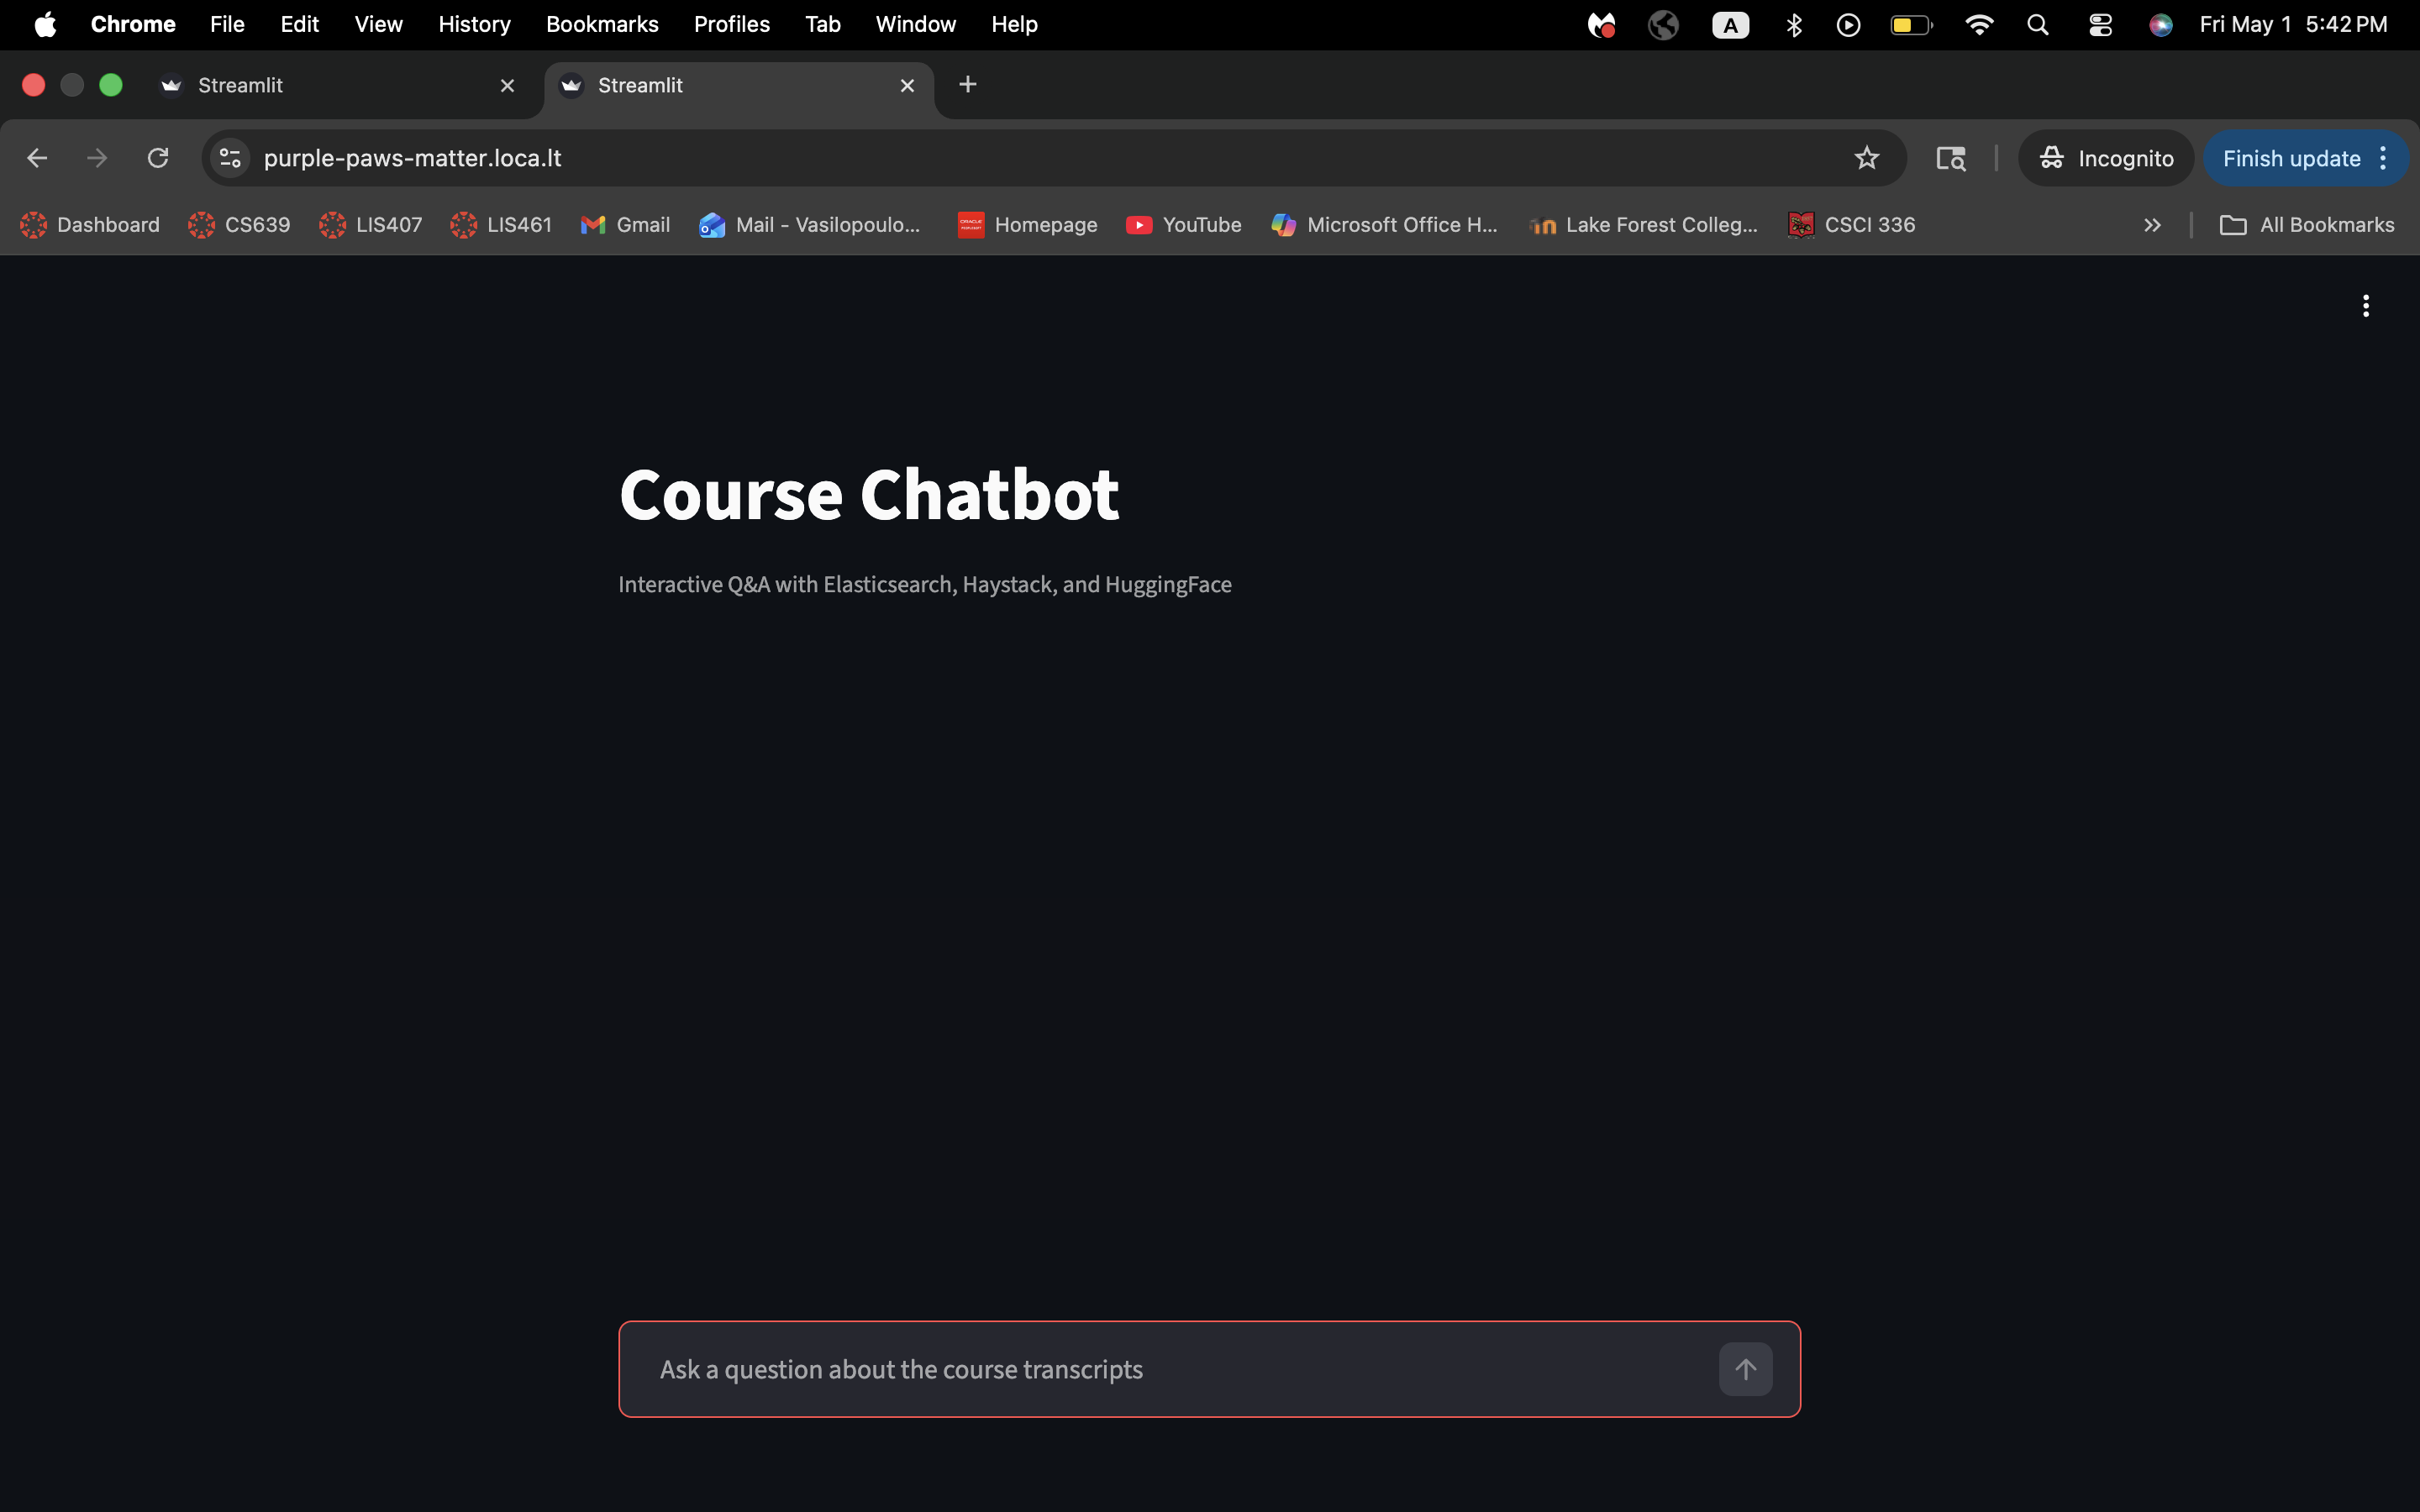

---
### Q3.3: Compare Fine-Tuning vs RAG

Test the same 3–5 prompts on both your fine-tuned LLM (from Section 2) and your RAG pipeline.

In [54]:
# TO IMPLEMENT
# Q3.3 — Run some(3-5) test prompts through the RAG pipeline to compare against the fine-tuned model output.
test_prompts = [
    "What NoSQL databases are covered in the CS 639 course?",
    "What are the main topics covered in the SQL lectures?",
    "Explain how Elasticsearch is used in this class."
]

for prompt in test_prompts:
    print(f"\n{'='*70}\nPrompt: {prompt}\n{'='*70}")
    result = rag_pipeline.run({
        "prompt_builder": {"query": prompt},
        "retriever": {"query": prompt}
    })
    try:
        print(f"RAG Response:\n{result['llm']['replies'][0].text}")
    except AttributeError:
        print(f"RAG Response:\n{result['llm']['replies'][0]}")


Prompt: What NoSQL databases are covered in the CS 639 course?
RAG Response:
Based on the provided context, the NoSQL databases covered in the CS 639: Data Management for Data Science course are:

1. MongoDB 
2. CouchDB

Prompt: What are the main topics covered in the SQL lectures?
RAG Response:
The main topics covered in the SQL lectures are:

1. Relational database
2. SQL (specifically, the GO operators)

These topics will be covered over the next couple of lectures.

Prompt: Explain how Elasticsearch is used in this class.
RAG Response:
Based on the given context, here's how Elasticsearch is used in this class:

1. **Data Indexing**: The data directory is created with a simple structure, indicating that the data is stored under "data" and has a similar structure to a GitHub class room repository.
2. **Indices**: A client object instance reference is used to create indices, and the method is `create`. This suggests that Elasticsearch is being used to create a new index, which is ess

**Q3.3 In a markdown cell, report:**
- **Which approach gave more accurate responses?**
- **Did the fine-tuned model hallucinate information?**
- **Was RAG better at answering new or unseen questions?**

Which approach gave more accurate responses?   
The RAG pipeline provided more accurate responses. It directly references the retrieved lecture chunks so it gave specific points (explicitly listing MongoDB and CouchDB, or detailing specific Elasticsearch use cases like aggregations and indexing, etc.) instead of just generating plausible-sounding text.

Did the fine-tuned model hallucinate information?    
Yes, the fine-tuned model still hallucinated. It succesfully learned the vocab and general domain of the course but it sometimes wrongly merged distinct concepts. It mentioned "schema design using JSON data types" when the question was about SQL lectures, which is a mix-up of NoSQL and relational concepts.    

Was RAG better at answering new or unseen questions?     
RAG is much better at answering unseen questions. Since it retrieves the exact relevant paragraphs from the actual lecture transcripts on the fly, there's no need to rely on data memorized in its weights. This makes it very reliable for factual course queries.